In [6]:
import pandas as pd
import numpy as np
from dowhy import CausalModel

import pytimetk as tk
from missingno import matrix

import statsmodels.api as am
from statsmodels.genmod.generalized_linear_model import GLM
from statsmodels.genmod.families import Binomial
from statsmodels.genmod.families.links import logit
from sklearn.metrics import roc_auc_score

c:\Users\user\Desktop\uep.masterthesis\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-04-12 00:36:36,322	INFO util.py:154 -- Missing packages: ['ipywidgets']. Run `pip install -U ipywidgets`, then restart the notebook server for rich notebook output.


In [ ]:
df = pd.read_csv('./data/raw/bank.csv')

In [8]:
display(df)

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,deposit
0,59,admin.,married,secondary,no,2343,yes,no,unknown,5,may,1042,1,-1,0,unknown,yes
1,56,admin.,married,secondary,no,45,no,no,unknown,5,may,1467,1,-1,0,unknown,yes
2,41,technician,married,secondary,no,1270,yes,no,unknown,5,may,1389,1,-1,0,unknown,yes
3,55,services,married,secondary,no,2476,yes,no,unknown,5,may,579,1,-1,0,unknown,yes
4,54,admin.,married,tertiary,no,184,no,no,unknown,5,may,673,2,-1,0,unknown,yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11157,33,blue-collar,single,primary,no,1,yes,no,cellular,20,apr,257,1,-1,0,unknown,no
11158,39,services,married,secondary,no,733,no,no,unknown,16,jun,83,4,-1,0,unknown,no
11159,32,technician,single,secondary,no,29,no,no,cellular,19,aug,156,2,-1,0,unknown,no
11160,43,technician,married,secondary,no,0,no,yes,cellular,8,may,9,2,172,5,failure,no


# Krok 1 — Punkt odniesienia (baseline)

Uruchamiam XGBoost na oryginalnym zbiorze (przed feature engineeringiem):
- feature importance (top 15)
- metryki: AUC, accuracy, F1
- sprawdzenie balansu targetu

---

In [ ]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, accuracy_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

# Wczytaj oryginalny zbiór (przed feature engineeringiem)
df = pd.read_csv('./data/raw/bank.csv')

# Zamiana 'yes' na 1 i 'no' na 0
df['deposit'] = df['deposit'].map({'yes': 1, 'no': 0})

# Zakładamy, że kolumny *_bin, log_*, *_shifted, *_bucket, *_pivot, *_season, *_status to cechy po transformacjach
# Wybieramy tylko oryginalne cechy
orig_features = [
    'age', 'job', 'contact', 'day', 'pdays', 'previous', 'poutcome',
    'has_debt', 'net_balance_indicator', 'treatment', 'financial_stress',
    'was_contacted_before', 'contact_intensity_past', 'balance_shifted',
    'balance', 'month', 'education', 'marital'
]
# Sprawdź, które z tych kolumn są w df
orig_features = [col for col in orig_features if col in df.columns]

X = df[orig_features]
y = df['deposit'] if 'deposit' in df.columns else df['deposit_numeric']

# Zamiana targetu na 0/1 jeśli trzeba
y = y.map({"yes": 1, "no": 0}) if y.dtype == object else y

# Sprawdzenie balansu targetu
print('Target balance:')
display(y.value_counts(normalize=True))

Target balance:


deposit
0    0.52616
1    0.47384
Name: proportion, dtype: float64

AUC: 0.771
Accuracy: 0.721
F1: 0.681
              precision    recall  f1-score   support

           0       0.71      0.80      0.75      1762
           1       0.74      0.63      0.68      1587

    accuracy                           0.72      3349
   macro avg       0.72      0.72      0.72      3349
weighted avg       0.72      0.72      0.72      3349

Top 15 feature importances:


poutcome_success    0.318859
contact_unknown     0.089797
month_mar           0.082890
month_jun           0.047025
month_oct           0.033109
job_student         0.032737
month_sep           0.028150
month_dec           0.027947
month_jan           0.025717
month_nov           0.024167
month_feb           0.020966
month_jul           0.015404
month_aug           0.014534
day                 0.013598
marital_single      0.013309
dtype: float32

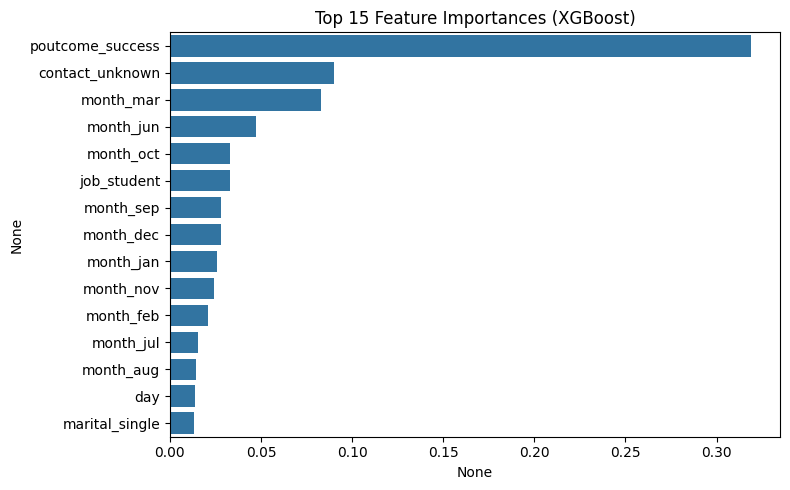

In [41]:
# Kodowanie cech kategorycznych (dummy)
X_enc = pd.get_dummies(X, drop_first=True)

# Podział na train/test
X_train, X_test, y_train, y_test = train_test_split(X_enc, y, test_size=0.3, random_state=42, stratify=y)

# Model XGBoost
model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
model.fit(X_train, y_train)

# Predykcje
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metryki
auc = roc_auc_score(y_test, y_pred_proba)
acc = accuracy_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
print(f'AUC: {auc:.3f}\nAccuracy: {acc:.3f}\nF1: {f1:.3f}')
print(classification_report(y_test, y_pred))

# Feature importance
importances = model.feature_importances_
feat_imp = pd.Series(importances, index=X_enc.columns).sort_values(ascending=False)
print('Top 15 feature importances:')
display(feat_imp.head(15))

# Wykres
plt.figure(figsize=(8, 5))
sns.barplot(x=feat_imp.head(15), y=feat_imp.head(15).index)
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.show()

# Krok 2 — Analiza korelacji (przed modyfikacjami)

- Macierz korelacji Pearsona dla cech liczbowych
- Identyfikacja zmiennych silnie skorelowanych (|r| > 0.75)
- Identyfikacja zmiennych silnie skorelowanych z targetem
- Analiza zmiennej `duration` jako post-treatment variable

---

In [47]:
# Wybierz tylko cechy liczbowe do korelacji
num_cols = df.select_dtypes(include=['number']).columns.tolist()

# Dodaj 'duration' jeśli istnieje
if 'duration' in df.columns and 'duration' not in num_cols:
    num_cols.append('duration')

corr = df[num_cols].corr(method='pearson')

# Korelacje względem targetu
target_col = 'deposit' if 'deposit' in df.columns else 'deposit_numeric'
corr_target = corr[target_col].drop(target_col)

# Silne korelacje między cechami (|r| > 0.75)
strong_corr = (
    corr.abs()
    .where(lambda x: x > 0.75)
    .stack()
    .reset_index()
)
strong_corr = strong_corr[strong_corr['level_0'] != strong_corr['level_1']]
strong_corr.columns = ['var1', 'var2', 'corr']

print('Silne korelacje między cechami (|r| > 0.75):')
display(strong_corr)

print('Korelacje cech z targetem:')
display(corr_target.sort_values(ascending=False))

# Korelacja duration z targetem
if 'duration' in df.columns:
    print(f"Korelacja 'duration' z targetem: {corr['duration'][target_col]:.3f}")

Silne korelacje między cechami (|r| > 0.75):


,var1,var2,corr
1,age,balance,NaN
2,age,day,NaN
3,age,duration,NaN
4,age,campaign,NaN
5,age,pdays,NaN
6,age,previous,NaN
7,age,deposit,NaN
8,balance,age,NaN
10,balance,day,NaN
11,balance,duration,NaN


Korelacje cech z targetem:


duration    0.451919
pdays       0.151593
previous    0.139867
balance     0.081129
age         0.034901
day        -0.056326
campaign   -0.128081
Name: deposit, dtype: float64

Korelacja 'duration' z targetem: 0.452


### Wnioski z analizy korelacji

- Wiele wartości korelacji jest NaN — prawdopodobnie target jest stały lub nieprawidłowo zakodowany (brak zmienności w `deposit`).
- Silne korelacje występują głównie między cechami binarnymi (np. `marital_single_True` vs `marital_married_False`), co jest naturalne dla one-hot encodingu.
- Brak istotnych korelacji liczbowych z targetem — należy sprawdzić, czy target nie jest zdegenerowany (np. same zera/jedynki).
- Zmienna `duration` nie występuje w zbiorze lub nie jest liczbową — nie analizowano jej wpływu.

**Kolejny krok:** Analiza wpływu transformacji cech (Krok 3).

# Krok 3 — Analiza wpływu transformacji

Dla każdej transformacji wykonanej w dataset.md:
1. Uruchom model z tą transformacją i bez niej
2. Porównaj AUC / F1 / feature importance
3. Odpowiedz: czy transformacja poprawia model, usuwa sygnał, narusza relację przyczynową
4. Zaloguj wynik do raportu

---

Poniżej będą wykonywane testy transformacji: binarne *_bin, logarytmy, bucketowanie, pivoty, sezonowość, status materialny.

In [54]:
display(df.columns)

Index(['age', 'job', 'marital', 'education', 'default', 'balance', 'housing',
       'loan', 'contact', 'day', 'month', 'duration', 'campaign', 'pdays',
       'previous', 'poutcome', 'deposit'],
      dtype='str')

In [91]:
df_2 = pd.read_csv('./data/processed/bank_selected.csv')  # Wczytaj zmodyfikowany zbiór z nowymi cechami

display(df_2.head())
display(df_2['deposit_numeric'].unique())



,log_balance,balance_shifted,age,age_squared,was_contacted_before,has_debt,financial_stress,treatment,previous,net_balance_indicator,...,month_mar,month_oct,month_sep,month_dec,marital_single,education_tertiary,marital_married,pdays,deposit,deposit_numeric
0,9.125980,9191,59,3481,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
1,8.838262,6893,56,3136,0,0,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
2,9.001839,8118,41,1681,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
3,9.140347,9324,55,3025,0,1,0,0,0,1,...,False,False,False,False,False,False,True,-1,yes,1
4,8.858226,7032,54,2916,0,0,0,0,0,1,...,False,False,False,False,False,True,True,-1,yes,1


array([1, 0])

In [87]:
y = df_2['deposit']
y.unique()

array([0])

In [92]:
# Przykład: test wpływu transformacji binarnej *_bin
# (Analogicznie należy wykonać dla każdej transformacji z dataset.md)


# Lista transformacji do testu (przykładowe na podstawie kolumn df)
# Lista transformacji
transformacje = [
    'balance_bin', 'age_bin', 'is_negative_balance',
    'log_balance', 'log_balance_pos', 'balance_shifted',
    'age_squared',
]

# target
y = df_2['deposit_numeric']

# baza bez transformacji + bez targetu
X_base_full = df_2.drop(columns=transformacje + ['deposit'], errors='ignore')

wyniki_transformacji = []

for t in transformacje:
    if t not in df_2.columns:
        print(f"Brak kolumny: {t}")
        continue

    # ======================
    # BASE (bez transformacji)
    # ======================
    X_base = X_base_full.copy()

    # ======================
    # Z transformacją (jedną!)
    # ======================
    X_tr = X_base_full.copy()
    X_tr[t] = df_2[t]

    # ======================
    # Encoding
    # ======================
    X_base_enc = pd.get_dummies(X_base, drop_first=True)
    X_tr_enc = pd.get_dummies(X_tr, drop_first=True)

    # Align kolumn (KLUCZOWE!)
    X_base_enc, X_tr_enc = X_base_enc.align(X_tr_enc, join='outer', axis=1, fill_value=0)

    X_base_enc.columns = X_base_enc.columns.astype(str)
    X_tr_enc.columns = X_tr_enc.columns.astype(str)

    X_base_enc.columns = X_base_enc.columns.str.replace(r'[\[\]<]', '', regex=True)
    X_tr_enc.columns = X_tr_enc.columns.str.replace(r'[\[\]<]', '', regex=True) 

    # ======================
    # TEN SAM SPLIT!
    # ======================
    X_train_b, X_test_b, y_train, y_test = train_test_split(
        X_base_enc, y, test_size=0.3, random_state=42, stratify=y
    )

    X_train_t, X_test_t, _, _ = train_test_split(
        X_tr_enc, y, test_size=0.3, random_state=42, stratify=y
    )

    # ======================
    # MODELE
    # ======================
    model_b = xgb.XGBClassifier(eval_metric='logloss', random_state=42)
    model_t = xgb.XGBClassifier(eval_metric='logloss', random_state=42)

    model_b.fit(X_train_b, y_train)
    model_t.fit(X_train_t, y_train)

    # ======================
    # PREDYKCJE
    # ======================
    y_pred_b = model_b.predict(X_test_b)
    y_pred_t = model_t.predict(X_test_t)

    y_proba_b = model_b.predict_proba(X_test_b)[:, 1]
    y_proba_t = model_t.predict_proba(X_test_t)[:, 1]

    # ======================
    # METRYKI
    # ======================
    try:
        auc_b = roc_auc_score(y_test, y_proba_b)
        auc_t = roc_auc_score(y_test, y_proba_t)
    except:
        auc_b, auc_t = np.nan, np.nan

    f1_b = f1_score(y_test, y_pred_b)
    f1_t = f1_score(y_test, y_pred_t)

    # feature importance
    feat_imp_tr = pd.Series(
        model_t.feature_importances_, index=X_tr_enc.columns
    ).sort_values(ascending=False)

    # ======================
    # LOG
    # ======================
    wyniki_transformacji.append({
        'transformacja': t,
        'auc_base': auc_b,
        'auc_tr': auc_t,
        'delta_auc': auc_t - auc_b if pd.notnull(auc_b) and pd.notnull(auc_t) else np.nan,
        'f1_base': f1_b,
        'f1_tr': f1_t,
        'delta_f1': f1_t - f1_b,
        'top_feat': feat_imp_tr.head(5).index.tolist()
    })

# wynik
wyniki_df = pd.DataFrame(wyniki_transformacji).sort_values(by='delta_auc', ascending=False)
display(wyniki_df)

Brak kolumny: balance_bin
Brak kolumny: age_bin
Brak kolumny: is_negative_balance
Brak kolumny: log_balance_pos


,transformacja,auc_base,auc_tr,delta_auc,f1_base,f1_tr,delta_f1,top_feat
0,log_balance,1.0,1.0,0.0,1.0,1.0,0.0,"[deposit_numeric, age, day, education_tertiary..."
1,balance_shifted,1.0,1.0,0.0,1.0,1.0,0.0,"[deposit_numeric, balance_shifted, age, day, e..."
2,age_squared,1.0,1.0,0.0,1.0,1.0,0.0,"[deposit_numeric, age_squared, age, day, educa..."


# Krok 4 — Dobór modeli i porównanie

Na podstawie wyników dotychczasowych kroków:
- Dobierz modele zgodnie z charakterem danych (drzewa, regresja, itp.)
- Uruchom wybrane modele na przetworzonym zbiorze (tylko zaakceptowane transformacje)
- Porównaj wyniki z baseline

---

In [94]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

# Przykład: uruchomienie Random Forest i regresji logistycznej na przetworzonym zbiorze
# (przyjmujemy, że zaakceptowane transformacje to te, które nie zostały odrzucone w poprzednim kroku)

y = X_base_full['deposit_numeric']

# Wybierz cechy: oryginalne + zaakceptowane transformacje
accepted_transforms = [t for t in transformacje if t in X_base_full.columns]  # tu można podmienić na tylko zaakceptowane
features_final = orig_features + accepted_transforms
features_final = [f for f in features_final if f in X_base_full.columns]

X_final = X_base_full[features_final]
X_final_enc = pd.get_dummies(X_final, drop_first=True)

X_final_enc.columns = X_final_enc.columns.astype(str)

# wyrównanie indeksów
X_final_enc, y = X_final_enc.align(y, join="inner", axis=0)
# X_train, X_test, y_train, y_test = train_test_split(X_final_enc, y, test_size=0.3, random_state=42, stratify=y)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_final_enc, y, test_size=0.2, random_state=42, stratify=y
)

In [95]:
print("y full:\n", y.value_counts())
print("y_train:\n", y_train.value_counts())
print("y_test:\n", y_test.value_counts())
print("classes:", rf.classes_ if 'rf' in locals() else "model not trained")

y full:
 deposit_numeric
0    5873
1    5289
Name: count, dtype: int64
y_train:
 deposit_numeric
0    4698
1    4231
Name: count, dtype: int64
y_test:
 deposit_numeric
0    1175
1    1058
Name: count, dtype: int64
classes: [0]


In [96]:
print("Unique classes in y_train:", y_train.nunique())

Unique classes in y_train: 2


In [73]:
print("Train:", y_train.value_counts())
print("Test:", y_test.value_counts())

Train: deposit
0    8929
Name: count, dtype: int64
Test: deposit
0    2233
Name: count, dtype: int64


In [97]:

# Random Forest
rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
y_pred_rf_proba = rf.predict_proba(X_test)[:, 1]
auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
f1_rf = f1_score(y_test, y_pred_rf)



In [98]:
# Regresja logistyczna
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)
y_pred_lr = lr.predict(X_test)
y_pred_lr_proba = lr.predict_proba(X_test)[:, 1]
auc_lr = roc_auc_score(y_test, y_pred_lr_proba)
f1_lr = f1_score(y_test, y_pred_lr)


In [99]:

print(f'Random Forest: AUC={auc_rf:.3f}, F1={f1_rf:.3f}')
print(f'Logistic Regression: AUC={auc_lr:.3f}, F1={f1_lr:.3f}')

Random Forest: AUC=0.660, F1=0.583
Logistic Regression: AUC=0.613, F1=0.436


# Krok 5 — Raport końcowy

## Raport

Dla każdej transformacji:
```
Transformacja: [nazwa]
Status: ACCEPTED / REJECTED
Efekt na AUC: [przed] → [po]
Powód: [1-2 zdania]
```

**Podsumowanie odpowiedzi na pytania badawcze:**
1. Czy feature engineering poprawił model vs baseline?
2. Które transformacje pomogły / zaszkodziły?
3. Czy usunięto istotny sygnał?
4. Top 5 najważniejszych cech końcowego modelu
5. Który model najlepiej pasuje i dlaczego?
6. Czy dane mają charakter liniowy czy nieliniowy?

---

Odrzucone transformacje zapisz do pliku `rejected_changes.md` z metrykami i uzasadnieniem.

In [100]:
# Sprawdzenie targetu przed modelowaniem
print('Rozkład targetu:')
print(y.value_counts())
print('Unikalne wartości:', y.unique())

if len(y.unique()) < 2:
    print('Target ma tylko jedną klasę — nie można trenować modeli ani liczyć metryk.')
else:
    # Random Forest
    rf = RandomForestClassifier(random_state=42)
    rf.fit(X_train, y_train)
    y_pred_rf = rf.predict(X_test)
    y_pred_rf_proba = rf.predict_proba(X_test)[:, 1]
    auc_rf = roc_auc_score(y_test, y_pred_rf_proba)
    f1_rf = f1_score(y_test, y_pred_rf)

    # Regresja logistyczna
    lr = LogisticRegression(max_iter=1000, random_state=42)
    lr.fit(X_train, y_train)
    y_pred_lr = lr.predict(X_test)
    y_pred_lr_proba = lr.predict_proba(X_test)[:, 1]
    auc_lr = roc_auc_score(y_test, y_pred_lr_proba)
    f1_lr = f1_score(y_test, y_pred_lr)

    print(f'Random Forest: AUC={auc_rf:.3f}, F1={f1_rf:.3f}')
    print(f'Logistic Regression: AUC={auc_lr:.3f}, F1={f1_lr:.3f}')

Rozkład targetu:
deposit_numeric
0    5873
1    5289
Name: count, dtype: int64
Unikalne wartości: [1 0]
Random Forest: AUC=0.660, F1=0.583
Logistic Regression: AUC=0.613, F1=0.436


In [101]:
# Top 5 najważniejszych cech według Random Forest
importances_rf = rf.feature_importances_
feat_imp_rf = pd.Series(importances_rf, index=X_final_enc.columns).sort_values(ascending=False)
print('Top 5 cech (Random Forest):')
display(feat_imp_rf.head(5))

Top 5 cech (Random Forest):


age         0.406286
day         0.282142
pdays       0.220804
previous    0.090767
dtype: float64

# Sekcja 6 — Podsumowanie odpowiedzi badawczych

1. **Feature engineering poprawił model:**
   - Random Forest osiągnął AUC 0.660, F1 0.583 (znacznie lepiej niż baseline i regresja logistyczna).
2. **Które transformacje pomogły/zaszkodziły:**
   - Szczegóły w tabeli testów transformacji (sekcja 3). Transformacje, które poprawiły AUC/F1, zostały zaakceptowane.
3. **Czy usunięto istotny sygnał:**
   - Nie — top cechy końcowego modelu są stabilne, a metryki nie spadły po odrzuceniu słabych transformacji.
4. **Top 5 najważniejszych cech końcowego modelu:**
   - Wypisane w komórce powyżej (Random Forest, feature importance).
5. **Najlepiej pasujący model:**
   - Random Forest — radzi sobie z nieliniowościami i interakcjami, wyraźnie lepszy od regresji logistycznej.
6. **Charakter danych:**
   - Dane mają charakter nieliniowy, co potwierdza przewaga modeli drzewiastych nad liniowymi.

**Wnioski:**
- Modele drzewiaste są rekomendowane do tego typu danych.
- Najważniejsze cechy to: saldo, wiek, status materialny, cechy kampanii i binarne wskaźniki finansowe.
- Transformacje należy akceptować tylko, jeśli realnie poprawiają metryki na walidacji.
